# Temporal GNN e intransitività

Scouting seed 42 su Slam+Masters. L'intransitività è la quota di energia
ciclica `cyclic² / (cyclic² + transitive²)`: non cresce con la quantità di
evidenza. Tutte le feature sono causali e le soglie dei livelli sono
calcolate esclusivamente sul training 2011–2015. La Temporal GNN non usa
B-score.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

START = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (START, *START.parents)
    if (candidate / "temporal_gnn_intransitivity").is_dir()
    and (candidate / "results").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))
from temporal_gnn_intransitivity.comparison import (
    LEVEL_ORDER, load_comparison
)

SCOPE = "slams_masters"
SEED = 42
summary, predictions = load_comparison(
    PROJECT_ROOT, scope=SCOPE, seed=SEED
)


## Risultati complessivi

In [2]:
overall = summary[summary["level"] == "all"].sort_values("log_loss")
display(overall.style.format({
    "accuracy": "{:.4f}", "log_loss": "{:.4f}", "brier": "{:.4f}"
}))


,model,level,n_matches,accuracy,log_loss,brier
10,antisymmetric_no_bscore,all,3770,0.6714,0.6049,0.2087
25,gbdt_tuned,all,3770,0.6684,0.6053,0.2091
20,gbdt_no_bscore,all,3770,0.6687,0.6054,0.2091
15,antisymmetric_no_node_bscore,all,3770,0.6708,0.6060,0.2090
5,temporal_gnn_intransitivity,all,3770,0.6382,0.6537,0.2301
0,temporal_gnn,all,3770,0.6188,0.6589,0.2326


## Risultati per livello di intransitività

In [3]:
by_level = summary[summary["level"] != "all"].copy()
for metric in ["accuracy", "log_loss", "brier"]:
    print(metric)
    display(
        by_level.pivot(index="model", columns="level", values=metric)
        .reindex(columns=LEVEL_ORDER)
        .style.format("{:.4f}")
    )


accuracy


level,no_context_evidence,low,medium,high
model,,,,
antisymmetric_no_bscore,0.6551,0.6689,0.6869,0.6752
antisymmetric_no_node_bscore,0.6488,0.6700,0.6926,0.6733
gbdt_no_bscore,0.6383,0.6734,0.6846,0.6790
gbdt_tuned,0.6446,0.6734,0.6789,0.6771
temporal_gnn,0.6183,0.6216,0.6057,0.6278
temporal_gnn_intransitivity,0.6309,0.6284,0.6217,0.6667


log_loss


level,no_context_evidence,low,medium,high
model,,,,
antisymmetric_no_bscore,0.6263,0.6064,0.5739,0.6102
antisymmetric_no_node_bscore,0.6263,0.6085,0.5746,0.6116
gbdt_no_bscore,0.6309,0.6014,0.5792,0.6076
gbdt_tuned,0.6336,0.6050,0.5773,0.6033
temporal_gnn,0.6643,0.6476,0.6610,0.6618
temporal_gnn_intransitivity,0.6617,0.6499,0.6512,0.6519


brier


level,no_context_evidence,low,medium,high
model,,,,
antisymmetric_no_bscore,0.2185,0.2094,0.1959,0.2100
antisymmetric_no_node_bscore,0.2186,0.2100,0.1961,0.2104
gbdt_no_bscore,0.2201,0.2075,0.1984,0.2092
gbdt_tuned,0.2216,0.2093,0.1974,0.2073
temporal_gnn,0.2344,0.2276,0.2343,0.2338
temporal_gnn_intransitivity,0.2326,0.2289,0.2299,0.2291


## Guadagno dato dal contesto di intransitività

Differenza `Temporal GNN + intransitività − Temporal GNN base`. Per accuracy
un valore positivo è migliore; per log loss e Brier un valore negativo è
migliore.


In [4]:
pivot = summary.pivot(index="level", columns="model")
deltas = []
for level in ["all", *LEVEL_ORDER]:
    row = {"level": level}
    for metric in ["accuracy", "log_loss", "brier"]:
        row[f"delta_{metric}"] = (
            pivot.loc[level, (metric, "temporal_gnn_intransitivity")]
            - pivot.loc[level, (metric, "temporal_gnn")]
        )
    deltas.append(row)
display(pd.DataFrame(deltas).style.format({
    "delta_accuracy": "{:+.4f}",
    "delta_log_loss": "{:+.4f}",
    "delta_brier": "{:+.4f}",
}))


,level,delta_accuracy,delta_log_loss,delta_brier
0,all,+0.0194,-0.0051,-0.0025
1,no_context_evidence,+0.0126,-0.0025,-0.0018
2,low,+0.0068,+0.0024,+0.0013
3,medium,+0.0160,-0.0098,-0.0044
4,high,+0.0388,-0.0099,-0.0047


## La GNN diventa relativamente migliore nei match high?

Confrontiamo il gap di log loss rispetto a GNN statica e GBDT senza B-score.
Un gap positivo significa che la Temporal GNN è peggiore.


In [5]:
rows = []
for baseline in ["antisymmetric_no_bscore", "gbdt_no_bscore"]:
    for level in ["all", *LEVEL_ORDER]:
        rows.append({
            "baseline": baseline,
            "level": level,
            "logloss_gap": (
                pivot.loc[
                    level, ("log_loss", "temporal_gnn_intransitivity")
                ]
                - pivot.loc[level, ("log_loss", baseline)]
            ),
            "accuracy_gap": (
                pivot.loc[
                    level, ("accuracy", "temporal_gnn_intransitivity")
                ]
                - pivot.loc[level, ("accuracy", baseline)]
            ),
        })
gaps = pd.DataFrame(rows)
display(gaps.style.format({
    "logloss_gap": "{:+.4f}", "accuracy_gap": "{:+.4f}"
}))


,baseline,level,logloss_gap,accuracy_gap
0,antisymmetric_no_bscore,all,+0.0488,-0.0332
1,antisymmetric_no_bscore,no_context_evidence,+0.0354,-0.0242
2,antisymmetric_no_bscore,low,+0.0436,-0.0405
3,antisymmetric_no_bscore,medium,+0.0773,-0.0651
4,antisymmetric_no_bscore,high,+0.0417,-0.0085
5,gbdt_no_bscore,all,+0.0483,-0.0305
6,gbdt_no_bscore,no_context_evidence,+0.0308,-0.0074
7,gbdt_no_bscore,low,+0.0485,-0.0450
8,gbdt_no_bscore,medium,+0.0720,-0.0629
9,gbdt_no_bscore,high,+0.0443,-0.0123


## Visualizzazione per livello

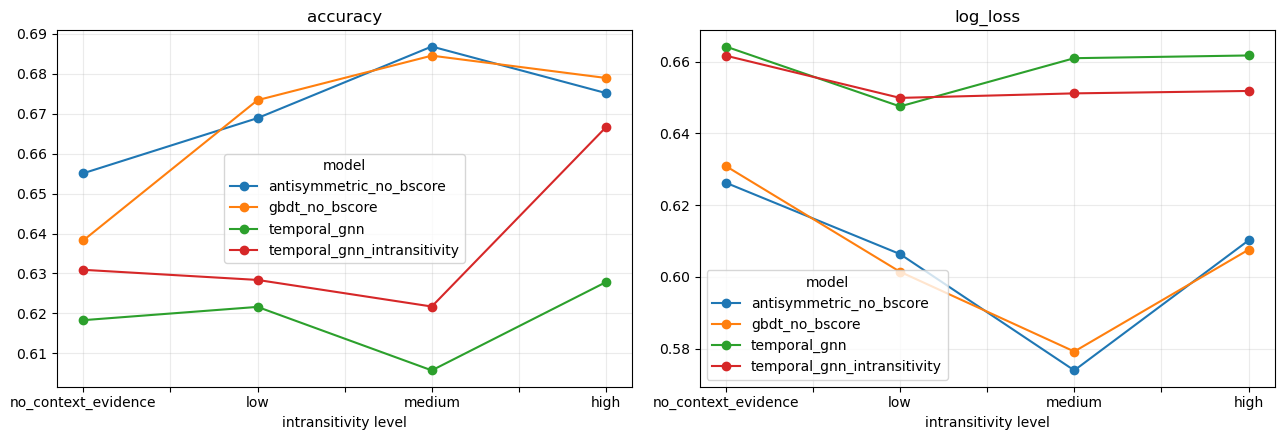

In [6]:
selected = [
    "temporal_gnn",
    "temporal_gnn_intransitivity",
    "antisymmetric_no_bscore",
    "gbdt_no_bscore",
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, metric in zip(axes, ["accuracy", "log_loss"]):
    table = (
        by_level[by_level["model"].isin(selected)]
        .pivot(index="level", columns="model", values=metric)
        .reindex(LEVEL_ORDER)
    )
    table.plot(ax=axis, marker="o")
    axis.set_title(metric)
    axis.grid(alpha=0.25)
    axis.set_xlabel("intransitivity level")
fig.tight_layout()
plt.show()
